# Breast Cancer Wisconsin (Diagnostic) - Complete EDA & R3 Diagnostic
### Risk-Aware Dynamic Model Router (R3) - Failure Window Benchmark

This notebook performs EDA on the Breast Cancer Wisconsin dataset ($N = 569$, $d = 30$).
It evaluates feature correlations, class ratios, outlier distributions, and computes the **R3 Diagnostic Operating Window** to demonstrate why highly correlated models favor static selection over dynamic routing.

In [1]:
# --- 1. Load Libraries & Dataset ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

print('Fetching Breast Cancer Wisconsin dataset from OpenML...')
wdbc = fetch_openml(data_id=15, as_frame=True, parser='auto')
df = wdbc.frame.copy()

print(f'Dataset Shape: {df.shape}')
df.head()

Fetching Breast Cancer Wisconsin dataset from OpenML...
Dataset Shape: (699, 10)


,Clump_Thickness,Cell_Size_Uniformity,Cell_Shape_Uniformity,Marginal_Adhesion,Single_Epi_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,benign
1,5,4,4,5,7,10.0,3,2,1,benign
2,3,1,1,1,2,2.0,3,1,1,benign
3,6,8,8,1,3,4.0,3,7,1,benign
4,4,1,1,3,2,1.0,3,1,1,benign


--- Data Info & Missing Values ---
Total Missing Values: 16
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Clump_Thickness        699 non-null    int64   
 1   Cell_Size_Uniformity   699 non-null    int64   
 2   Cell_Shape_Uniformity  699 non-null    int64   
 3   Marginal_Adhesion      699 non-null    int64   
 4   Single_Epi_Cell_Size   699 non-null    int64   
 5   Bare_Nuclei            683 non-null    float64 
 6   Bland_Chromatin        699 non-null    int64   
 7   Normal_Nucleoli        699 non-null    int64   
 8   Mitoses                699 non-null    int64   
 9   Class                  699 non-null    category
dtypes: category(1), float64(1), int64(8)
memory usage: 50.1 KB
None

--- Target Distribution ---
           Count  Percentage (%)
Class                           
benign       458       65.522175
ma

/tmp/ipykernel_720/1901634026.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette='Set1')


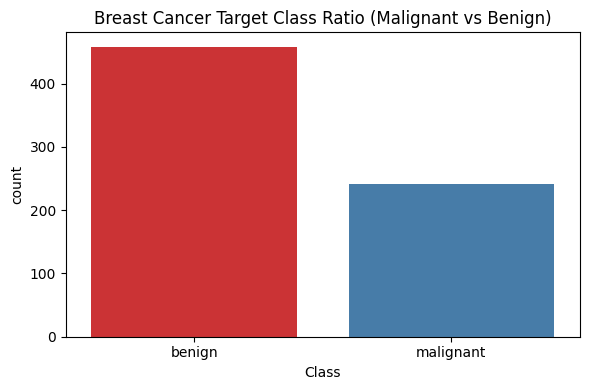

In [2]:
# --- 2. Data Audit & Missing Value Inspection ---
target_col = 'Class' if 'Class' in df.columns else 'target'

print('--- Data Info & Missing Values ---')
print(f'Total Missing Values: {df.isnull().sum().sum()}')
print(df.info())

# Class Imbalance Profile
class_counts = df[target_col].value_counts()
class_pct = df[target_col].value_counts(normalize=True) * 100
print('\n--- Target Distribution ---')
print(pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pct}))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette='Set1')
plt.title('Breast Cancer Target Class Ratio (Malignant vs Benign)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_720/1323712787.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=key_features[0], ax=axes[0], palette='coolwarm')


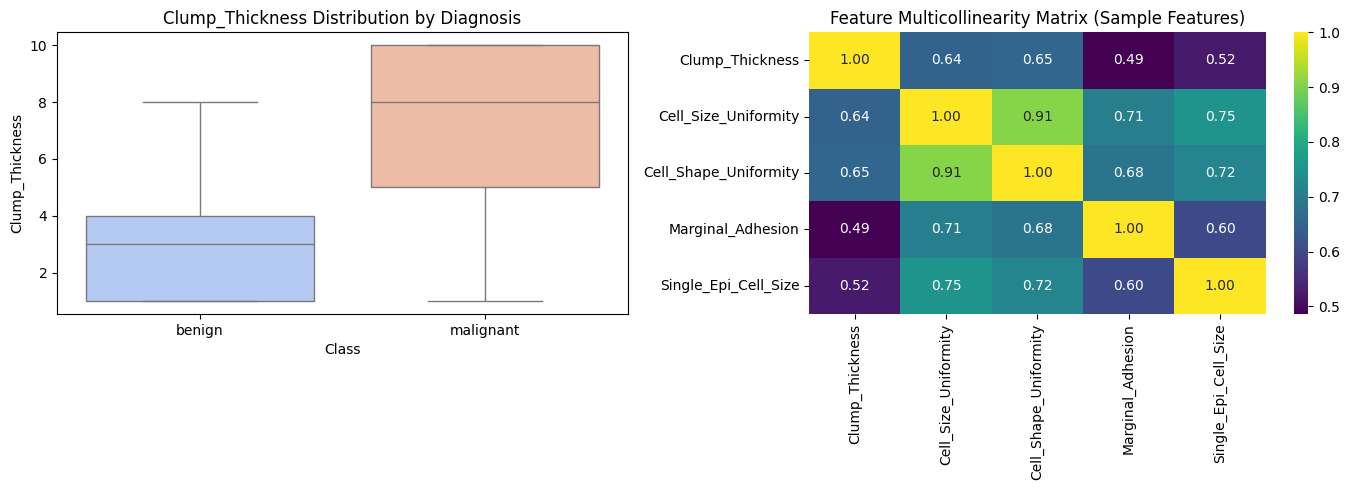

In [4]:
# Select all numeric feature columns except the target
key_features = [col for col in df.columns if col != target_col and df[col].dtype != 'category'][:5]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot of the first feature by Target
sns.boxplot(data=df, x=target_col, y=key_features[0], ax=axes[0], palette='coolwarm')
axes[0].set_title(f'{key_features[0]} Distribution by Diagnosis')

# Correlation Matrix of Sample Continuous Features
num_df = df.drop(columns=[target_col]).apply(pd.to_numeric, errors='coerce')
sns.heatmap(num_df[key_features].corr(), annot=True, cmap='viridis', ax=axes[1], fmt='.2f')
axes[1].set_title('Feature Multicollinearity Matrix (Sample Features)')

plt.tight_layout()
plt.show()

In [6]:
# --- 4. R3 Diagnostic Operating Window Metrics ---
from sklearn.impute import SimpleImputer

X = df.drop(columns=[target_col])
y = (df[target_col].astype(str).str.contains('2|malignant|1')).astype(int).values

# Missing values handle karne ke liye Median Imputer
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Continuous features ko scale karein
scaler = StandardScaler()
X_proc = scaler.fit_transform(X_imputed)

# 5-Fold Cross Validation for OOF Signals
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LR': LogisticRegression(max_iter=1000),
    'XGB': HistGradientBoostingClassifier(),
    'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)
}

oof_probs = {m: np.zeros((len(y), 2)) for m in models}

for train_idx, val_idx in skf.split(X_proc, y):
    X_tr, X_val = X_proc[train_idx], X_proc[val_idx]
    y_tr = y[train_idx]

    for name, model in models.items():
        model.fit(X_tr, y_tr)
        oof_probs[name][val_idx] = model.predict_proba(X_val)

# Failure Vectors R_M(x)
accs, failures = {}, {}
for name in models:
    preds = np.argmax(oof_probs[name], axis=1)
    accs[name] = accuracy_score(y, preds)
    failures[name] = (preds != y).astype(int)

# Oracle Accuracy & Headroom (Delta_Oracle)
oracle_correct = np.any([failures[m] == 0 for m in models], axis=0)
acc_oracle = np.mean(oracle_correct)
best_static_acc = max(accs.values())
delta_oracle = acc_oracle - best_static_acc

# Pairwise Error Correlation (rho_e)
rho_list = []
keys = list(models.keys())
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        r_i, r_j = failures[keys[i]], failures[keys[j]]
        rho_list.append(np.corrcoef(r_i, r_j)[0, 1])

avg_rho = np.mean(rho_list)

print('==================================================')
print('  BREAST CANCER DATASET - R3 DIAGNOSTIC EVALUATION ')
print('==================================================')
for m in models:
    print(f'Base Model Accuracy [{m}]: {accs[m]*100:.2f}%')

print(f'Best Static Model Acc     : {best_static_acc*100:.2f}%')
print(f'Oracle Upper Bound Acc    : {acc_oracle*100:.2f}%')
print(f'Oracle Headroom (Delta)   : {delta_oracle*100:.2f}%')
print(f'Pairwise Error Corr (rho) : {avg_rho:.3f}')
print('--------------------------------------------------')

if delta_oracle >= 0.03 and avg_rho <= 0.45:
    print('STATUS: PASS -> Dataset is OPTIMAL for R3 Dynamic Routing')
else:
    print('STATUS: FAIL -> Static ensemble recommended (High Error Correlation / Low Headroom)')
print('==================================================')

  BREAST CANCER DATASET - R3 DIAGNOSTIC EVALUATION 
Base Model Accuracy [LR]: 96.57%
Base Model Accuracy [XGB]: 96.42%
Base Model Accuracy [MLP]: 95.99%
Best Static Model Acc     : 96.57%
Oracle Upper Bound Acc    : 97.71%
Oracle Headroom (Delta)   : 1.14%
Pairwise Error Corr (rho) : 0.706
--------------------------------------------------
STATUS: FAIL -> Static ensemble recommended (High Error Correlation / Low Headroom)
